# AnalysisTools — Unified Interface Demo

One syntax across snapshots, halo catalogues, merger trees, and SHARK
galaxy catalogues: `at.load()` sniffs the kind and format, every source
answers to the same `Dataset` interface (`ds["field"]`, `.select()`,
`.meta`, `.summary()`), and `Simulation` ties matched products together
with cross-matching. See `DEVELOPMENT.md` for the design.

This notebook runs on the small example data shipped in `data/`
(a 262k-particle SWIFT snapshot at z=0, its VELOCIraptor catalogue,
and the TreeFrog walkable tree).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import analysistools as at
from analysistools.api import plotting as plt2

SNAP  = "../data/snap_0031.hdf5"
HALOS = "../data/halos/snap_0031.VELOCIraptor.properties.0"
TREE  = "../data/VELOCIraptor.walkabletree.hdf5"

## 1. Load anything with one call

Kind, format, and (for snapshots) the writing convention are sniffed
from the file. Nothing is read from disk until the first field access.

In [2]:
snap  = at.load(SNAP)                 # -> SnapshotDataset (SWIFT, sniffed)
halos = at.load(HALOS, snapnum=31)    # -> HaloCatalogue (VELOCIraptor)

snap, halos

(<SnapshotDataset 'snap_0031.hdf5' kind=snapshot n=?>,
 <HaloCatalogue 'snap_0031.VELOCIraptor.properties.0' kind=halos n=?>)

In [3]:
halos.summary()

HaloCatalogue (halos)
  label:  snap_0031.VELOCIraptor.properties.0
  path:   ../data/halos/snap_0031.VELOCIraptor.properties.0
  format: VELOCIraptor
  rows:   522
  redshift: 0.0
  boxsize: 142.2475106685633
  scale_factor: 1.0
  fields: Aperture_mass_100_kpc, Aperture_mass_10_kpc, Aperture_mass_30_kpc, Aperture_mass_50_kpc, Aperture_mass_5_kpc, Aperture_npart_100_kpc, Aperture_npart_10_kpc, Aperture_npart_30_kpc, Aperture_npart_50_kpc, Aperture_npart_5_kpc, Aperture_rhalfmass_100_kpc, Aperture_rhalfmass_10_kpc, Aperture_rhalfmass_30_kpc, Aperture_rhalfmass_50_kpc, Aperture_rhalfmass_5_kpc, Aperture_veldisp_100_kpc, Aperture_veldisp_10_kpc, Aperture_veldisp_30_kpc, Aperture_veldisp_50_kpc, Aperture_veldisp_5_kpc, Efrac, Ekin, Epot, ID_mbp, ID_minpot, Krot, Lx, Lx_200crit, Lx_200crit_excl, Lx_200mean, Lx_200mean_excl, Lx_BN98, Lx_BN98_excl, Ly, Ly_200crit, Ly_200crit_excl, Ly_200mean, Ly_200mean_excl, Ly_BN98, Ly_BN98_excl, Lz, Lz_200crit, Lz_200crit_excl, Lz_200mean, Lz_200mean_excl,

## 2. Common field vocabulary and chainable selections

`pos`, `vel`, `mass`, `id`, `radius`, ... mean the same thing on every
source; native fields pass through untouched. Per-species views keep the
old muscle memory (`snap.dm.pos`). Selections are lightweight views:
geometric cuts and attribute cuts chain, and every view is a Dataset.

In [4]:
row = int(np.argmax(halos["mass"]))          # most massive halo
c, r200 = halos["pos"][row], halos["radius"][row]

parts = snap.dm.select(centre=c, size=2 * r200)      # periodic sphere
big   = halos.select(mass=(np.percentile(halos["mass"], 90), None))

print(f"most massive halo: M = {halos['mass'][row]:.3e}, R200 = {r200:.3f}")
print(f"{len(parts):,} DM particles within 2 R200; "
      f"{len(big)} halos in the top decile")

Reading snapshot data...
Reading data from ../data/snap_0031.hdf5
Simulation scale factor: [1.]
Number of particles: 262144
Number of particle types: 7
False
most massive halo: M = 6.443e+04, R200 = 1.777
2,050 DM particles within 2 R200; 53 halos in the top decile


## 3. Dataset-aware plotting

`plotting` accepts Datasets directly and delegates the numerics to
`GriddingTools` / `ProfileTools`. Sources combine by drawing on the same
axes — here the projected DM surface density with catalogue halos
over-plotted.

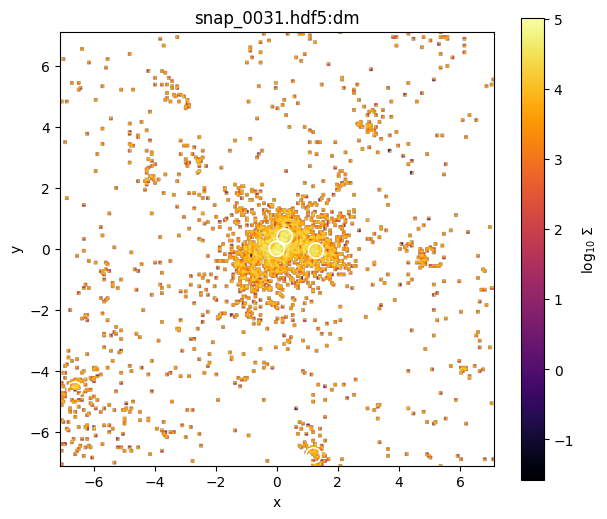

In [5]:
ax = plt2.density_map(snap.dm, centre=c, size=4 * r200,
                      grid_size=256, method="CIC")
near = halos.select(centre=c, size=4 * r200, geometry="cubic")
plt2.overlay_points(ax, near, centre=c, s=120)
plt.show()

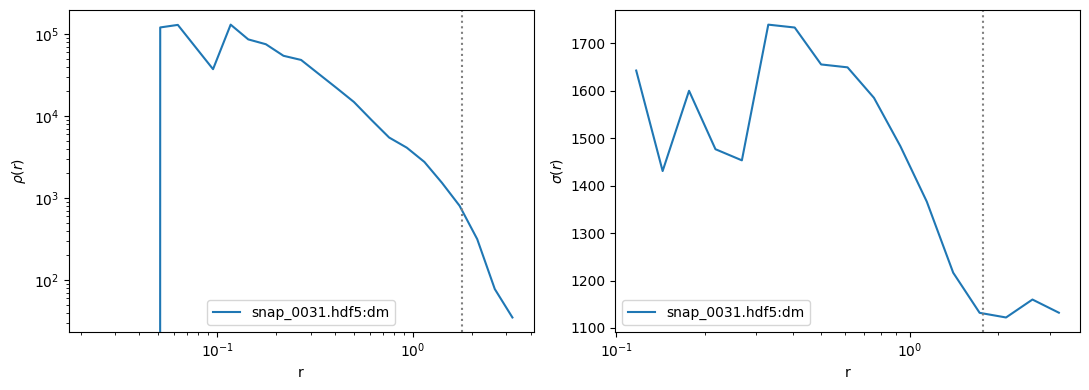

In [6]:
prof = plt2.profile(snap.dm, c, kind="density",
                    rmin=0.02, rmax=2 * r200, nbins=25)
sig  = plt2.profile(snap.dm, c, kind="velocity_dispersion",
                    rmin=0.02, rmax=2 * r200, nbins=25)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
plt2.plot_profile(prof, ax=a1)
plt2.plot_profile(sig, ax=a2, logy=False)
a1.axvline(r200, ls=":", c="grey"); a2.axvline(r200, ls=":", c="grey")
plt.tight_layout(); plt.show()

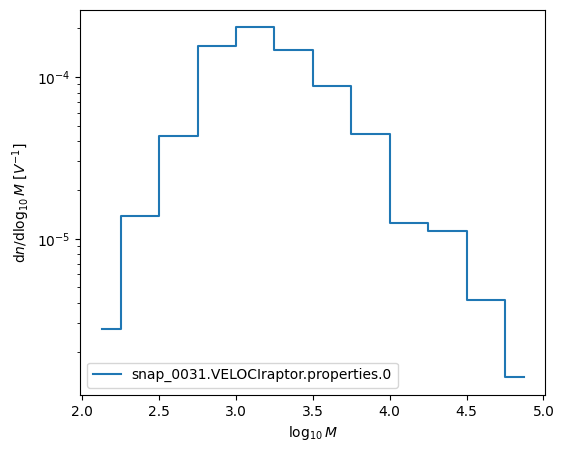

In [7]:
res = plt2.mass_function(halos, dlog10m=0.25)
plt.show()

## 4. Merger trees

Tree queries return `TrackDataset` (rows = snapshots, earliest first) —
the full Dataset contract again. With a linked catalogue, walkable-tree
tracks fill Mass/Pos/Vel at every epoch a catalogue is available.

In [8]:
tree  = at.load(TREE, halos=halos)
track = tree.from_halo(halos, index=row)

print(track)
print(f"track spans z = {track['redshift'][0]:.2f} -> "
      f"{track['redshift'][-1]:.2f} over {len(track)} snapshots")
print("infall:", track.infall())

<TrackDataset 'VELOCIraptor.walkabletree.hdf5:31000000000001' kind=tree n=17, z=0>
track spans z = 2.33 -> 0.00 over 17 snapshots
infall: None


## 5. The Simulation umbrella

`Simulation` binds matched products; `sim.at(z)` gives an `Epoch` of
lazily-loaded views at the nearest available redshift, with
cross-matching built in (`particles_in_halo`, `galaxies_in_halo`,
`track_of`). Galaxy matching is by position (periodic KD-tree) by
default, `match_by="id"` optional.

In [9]:
sim = at.Simulation(
    snapshots={0.0: SNAP},
    halos={0.0: HALOS},
    trees=TREE,
    snapnums={0.0: 31},
    label="demo",
)
epoch = sim.at(0.0)

parts = epoch.particles_in_halo(index=row, r_scale=2.0)
tr    = epoch.track_of(index=row)

print(epoch)
print(f"{len(parts):,} particles within 2 R200 of halo {row}")
print(f"track mass at z=0: {tr['mass'][-1]:.3e} "
      f"(catalogue: {epoch.halos['mass'][row]:.3e})")

Reading snapshot data...
Reading data from ../data/snap_0031.hdf5
Simulation scale factor: [1.]
Number of particles: 262144
Number of particle types: 7
False


<Epoch z=0 of 'demo' [snapshots, halos, trees]>
2,050 particles within 2 R200 of halo 0
track mass at z=0: 6.443e+04 (catalogue: 6.443e+04)


## 6. Mass accretion history

Everything composes: the track is a Dataset, so its columns plot like
any other.

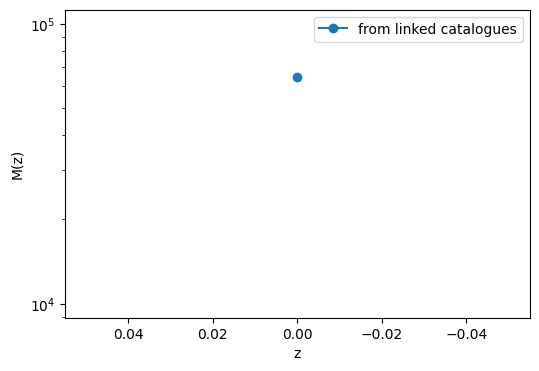

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
m = tr["mass"]
ok = np.isfinite(m)
ax.plot(tr["redshift"], np.where(ok, m, np.nan), "o-",
        label="from linked catalogues")
ax.set_xlabel("z"); ax.set_ylabel("M(z)")
ax.set_yscale("log"); ax.invert_xaxis(); ax.legend()
plt.show()

---
*Generated by `analysistools/api/_build_demo_notebook.py`; regenerate
after API changes. The legacy notebook
(`PlotSimulationAnalysis.ipynb`) predates the unified interface.*